In [ ]:
!pip install streamlit tensorflow==2.12.1 numpy==1.23.5 pmdarima==2.0.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of altair to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.8/857.8 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np
import tensorflow as tf
import pmdarima as pm

print(f"NumPy: {np.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"pmdarima: {pm.__version__}")

NumPy: 1.23.5
TensorFlow: 2.12.1
pmdarima: 2.0.3


Enter a valid stock label (e.g., AAPL, TSLA): TSLA
Successfully added TSLA to the dataframe.


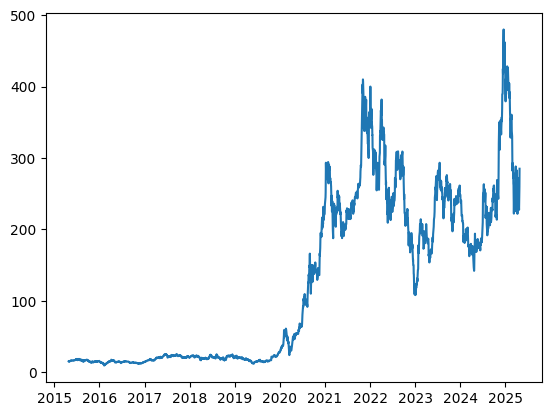

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pmdarima as pm
import streamlit as st
from sklearn.model_selection import train_test_split as ttsLSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error
from pmdarima.model_selection import train_test_split as ttsA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error


data = {}

def add_stock(ticker):
    try:
        stock = yf.Ticker(ticker)
        stock_df = stock.history(period="10y")  # max
        if stock_df.empty:
            print("Invalid stock label. Please try again.")
        else:
            data[ticker] = stock_df
            print(f"Successfully added {ticker} to the dataframe.")
    except Exception as e:
        print(f"Error fetching data: {e}")

stock_label = input("Enter a valid stock label (e.g., AAPL, TSLA): ").upper()
add_stock(stock_label)

df = data[stock_label]


plt.plot(df.index, df['Close'])



In [ ]:
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-04-27 00:00:00-04:00,14.837333,15.916667,14.800000,15.436667,175089000,0.0,0.0
2015-04-28 00:00:00-04:00,15.650000,15.700000,15.202000,15.365333,91281000,0.0,0.0
2015-04-29 00:00:00-04:00,15.336667,15.664667,15.175333,15.496667,59041500,0.0,0.0
2015-04-30 00:00:00-04:00,15.359333,15.526000,15.011333,15.070000,58678500,0.0,0.0
2015-05-01 00:00:00-04:00,15.329333,15.451333,14.694000,15.068667,79225500,0.0,0.0
...,...,...,...,...,...,...,...
2025-04-21 00:00:00-04:00,230.259995,232.210007,222.789993,227.500000,97768000,0.0,0.0
2025-04-22 00:00:00-04:00,230.960007,242.789993,229.850006,237.970001,120858500,0.0,0.0
2025-04-23 00:00:00-04:00,254.860001,259.450012,244.429993,250.740005,150381900,0.0,0.0


In [ ]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03,2516.0,2516.000000
mean,125.051178,127.861808,122.033405,125.010706,1.132953e+08,0.0,0.003180
std,118.474100,121.188174,115.447562,118.346536,7.385942e+07,0.0,0.116227
min,9.488000,10.331333,9.403333,9.578000,1.062000e+07,0.0,0.000000
25%,18.011834,18.332832,17.740667,18.065167,6.792225e+07,0.0,0.000000
50%,52.695333,54.209335,50.916668,52.990334,9.429285e+07,0.0,0.000000
75%,229.307503,234.570007,223.527504,229.595833,1.315992e+08,0.0,0.000000
max,475.899994,488.540009,457.510010,479.859985,9.140820e+08,0.0,5.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-04-27 00:00:00-04:00 to 2025-04-25 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2516 non-null   float64
 1   High          2516 non-null   float64
 2   Low           2516 non-null   float64
 3   Close         2516 non-null   float64
 4   Volume        2516 non-null   int64  
 5   Dividends     2516 non-null   float64
 6   Stock Splits  2516 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 157.2 KB


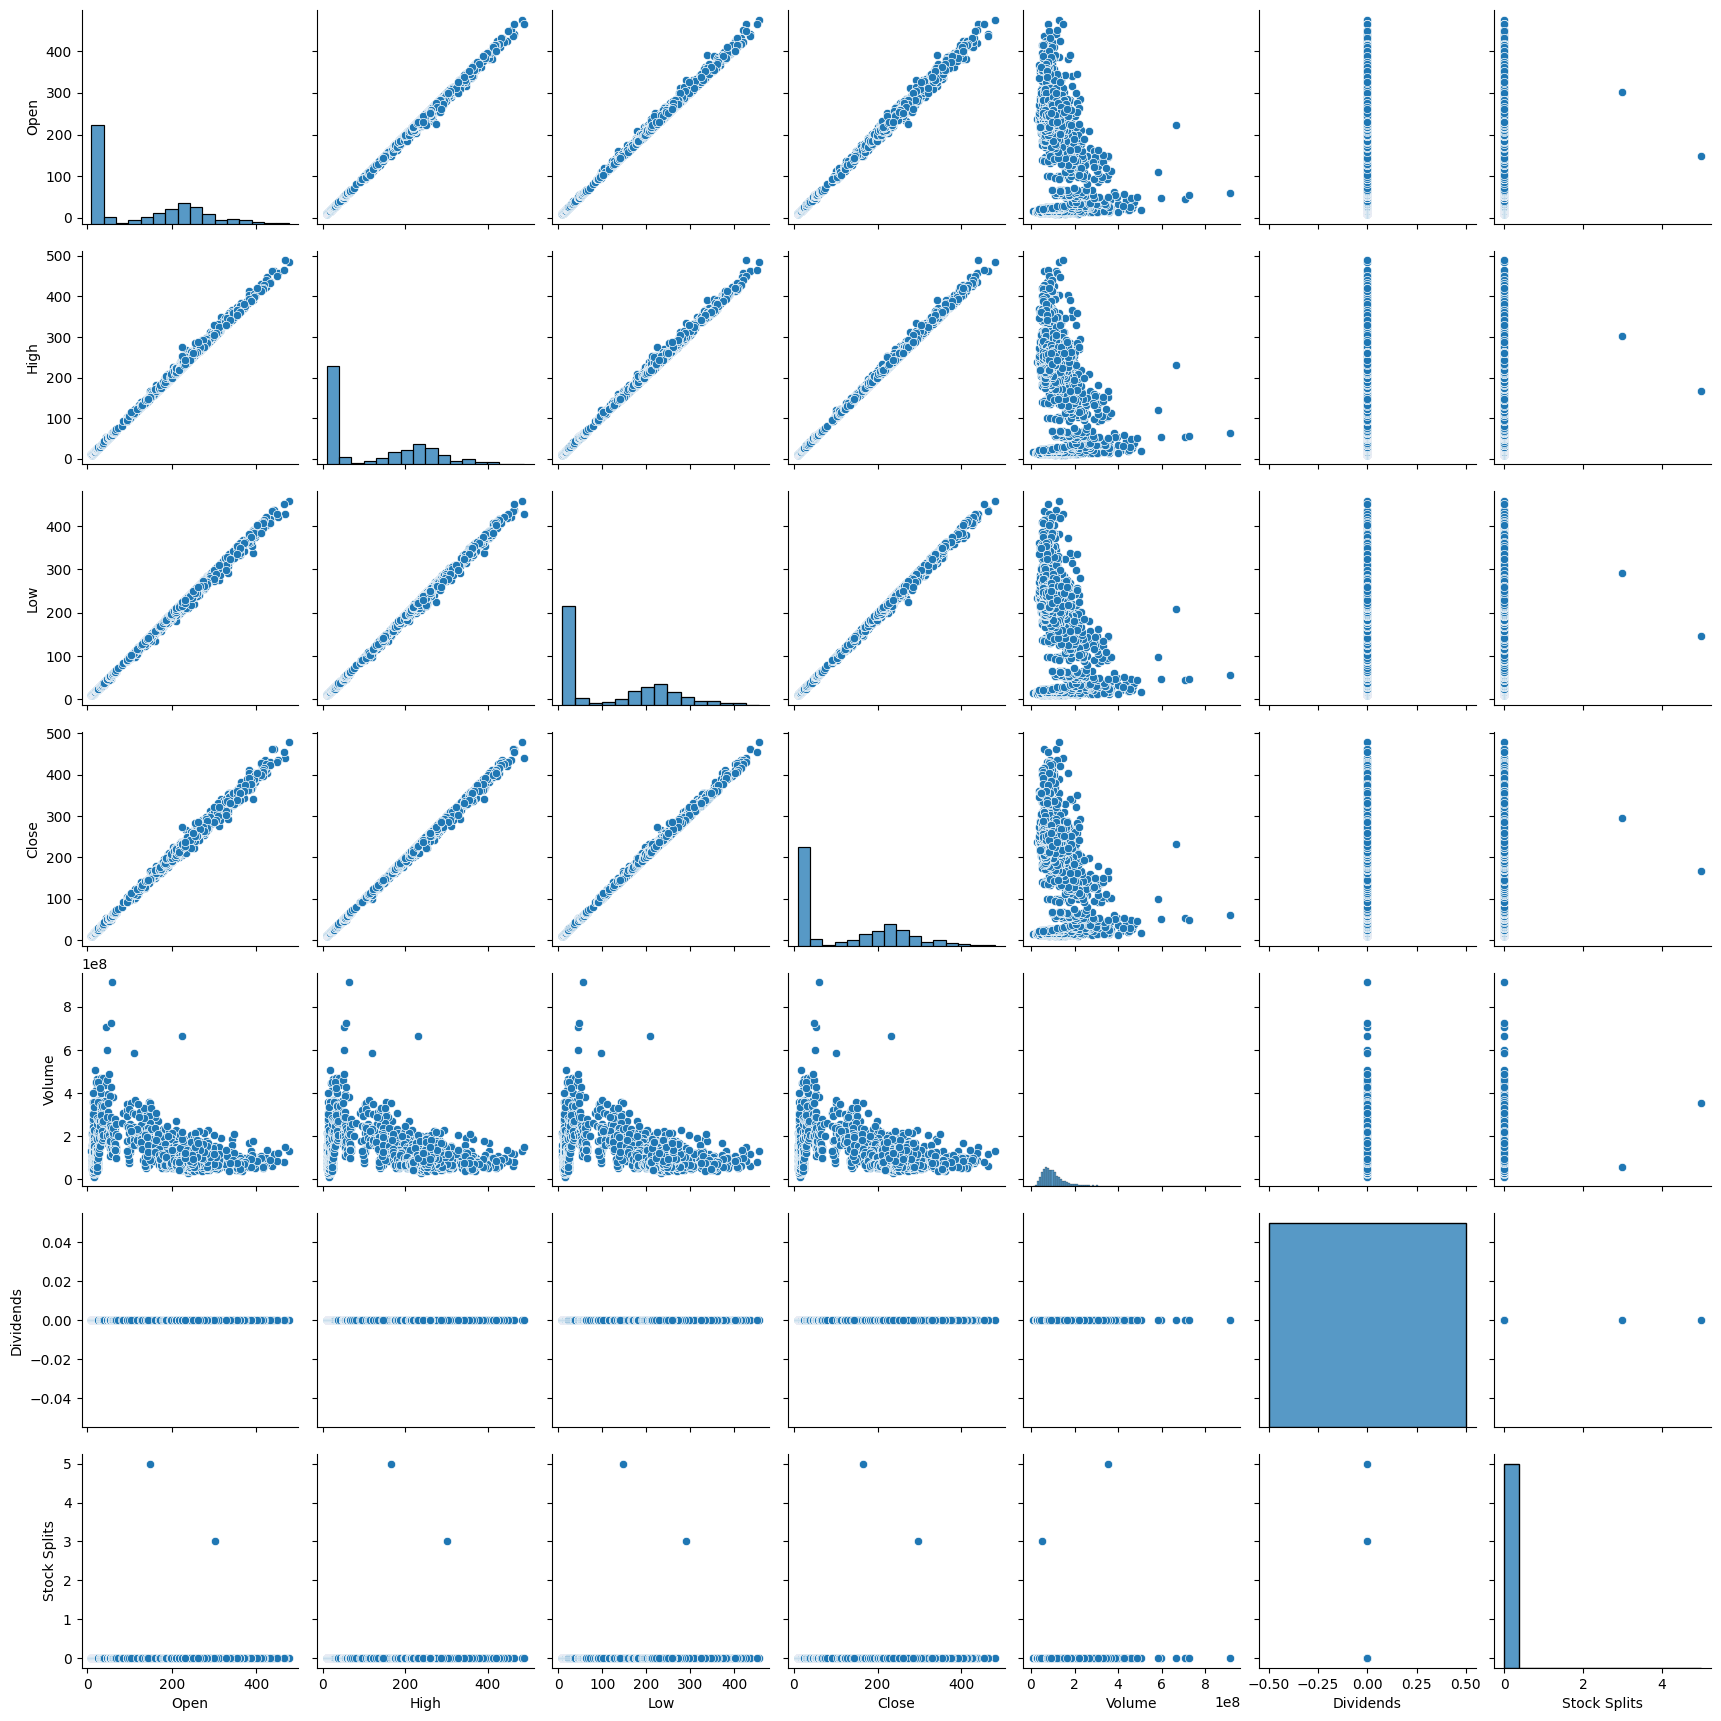

In [ ]:
sns.pairplot(df)

In [ ]:
#TrainTestSplit below
train_data, test_data = ttsLSTM(df[['Close']], test_size=0.2, shuffle=False)
train_data, val_data = ttsLSTM(train_data, test_size=0.2, shuffle=False)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [ ]:

train_data['Close'] = scaler.fit_transform(train_data['Close'].values.reshape(-1, 1))
val_data['Close'] = scaler.transform(val_data['Close'].values.reshape(-1, 1))
test_data['Close'] = scaler.transform(test_data['Close'].values.reshape(-1, 1))


In [ ]:
seq_length = 60



def create_sequences(data, dates, seq_length):
    X, y, dates_out = [], [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
        dates_out.append(dates[i+seq_length])  # Capture corresponding date
    return np.array(X), np.array(y), np.array(dates_out)




In [ ]:

X_train, y_train, train_dates = create_sequences(train_data['Close'].values, train_data.index, seq_length)
X_val, y_val, val_dates = create_sequences(val_data['Close'].values, val_data.index, seq_length)
X_test, y_test, test_dates = create_sequences(test_data['Close'].values, test_data.index, seq_length)


In [ ]:
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

X_train: (1549, 60), y_train: (1549,)


In [ ]:

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])



# # Add early stopping
# from tensorflow.keras.callbacks import EarlyStopping
# early_stop = EarlyStopping(monitor='val_loss', patience=5)
# model.fit(X_train, y_train, epochs=100, batch_size=32,
#           validation_data=(X_val, y_val), callbacks=[early_stop])

model.compile(optimizer='adam', loss='mean_squared_error')


In [ ]:
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/50
49/49 [==============================] - 23s 204ms/step - loss: 0.0081 - val_loss: 0.0123
Epoch 2/50
49/49 [==============================] - 7s 148ms/step - loss: 0.0010 - val_loss: 0.0104
Epoch 3/50
49/49 [==============================] - 10s 202ms/step - loss: 0.0011 - val_loss: 0.0104
Epoch 4/50
49/49 [==============================] - 8s 171ms/step - loss: 0.0011 - val_loss: 0.0124
Epoch 5/50
49/49 [==============================] - 7s 148ms/step - loss: 0.0010 - val_loss: 0.0104
Epoch 6/50
49/49 [==============================] - 8s 170ms/step - loss: 8.3280e-04 - val_loss: 0.0116
Epoch 7/50
49/49 [==============================] - 8s 173ms/step - loss: 8.8724e-04 - val_loss: 0.0083
Epoch 8/50
49/49 [==============================] - 7s 147ms/step - loss: 8.8094e-04 - val_loss: 0.0072
Epoch 9/50
49/49 [==============================] - 9s 194ms/step - loss: 9.4538e-04 - val_loss: 0.0094
Epoch 10/50
49/49 [==============================] - 8s 171ms/step - loss: 7.1258e

In [ ]:
predictions = model.predict(X_test)

14/14 [==============================] - 2s 46ms/step


In [ ]:
# Invert scaling to get actual stock prices
predictions = scaler.inverse_transform(predictions)

In [ ]:
y_test = y_test.reshape(-1, 1)
y_test_real = scaler.inverse_transform(y_test)

mse = mean_squared_error(y_test_real, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_real - predictions) / y_test_real)) * 100

#ACCURACY RESULT needed

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape:.2f}%")

MSE: 349.54981509381423
RMSE: 18.696251364747273


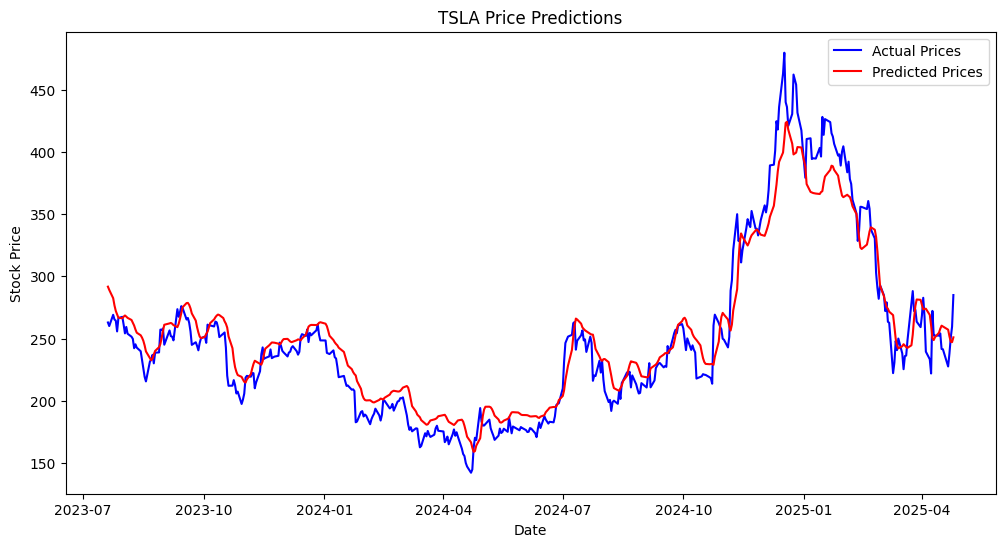

In [ ]:
#Actual versus Predicted
plt.figure(figsize=(12,6))
plt.plot(test_dates, y_test_real, label="Actual Prices", color='blue')
plt.plot(test_dates, predictions, label="Predicted Prices", color='red')
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title(f"{stock_label} Price Predictions")
plt.legend()
plt.show()

In [ ]:
#Signal generation (Buy and Sell)
def generate_signals(predictions, actual_prices, dates, threshold=0.02):
    signals = []
    for i in range(1, len(predictions)):
        pred_change = (predictions[i] - actual_prices[i-1])/actual_prices[i-1]
        if pred_change > threshold:
            signals.append(('BUY', actual_prices[i], dates[i]))
        elif pred_change < -threshold:
            signals.append(('SELL', actual_prices[i], dates[i]))
        else:
            signals.append(('HOLD', actual_prices[i], dates[i]))
    return signals

# Generate signals with dates
signals = generate_signals(predictions.flatten(), y_test_real.flatten(), test_dates)


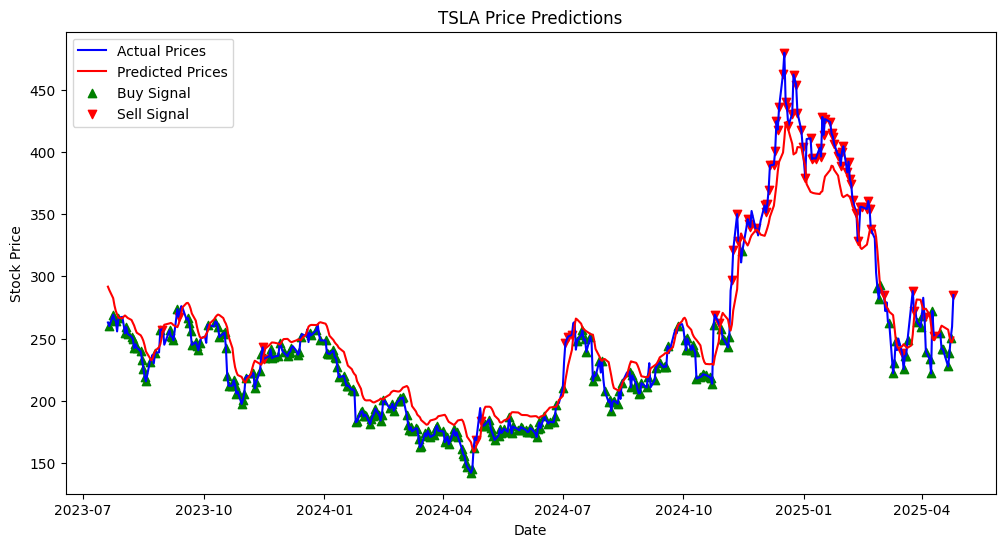

In [ ]:
#Buy and sell signals
plt.figure(figsize=(12,6))
plt.plot(test_dates, y_test_real, label="Actual Prices", color='blue')
plt.plot(test_dates, predictions, label="Predicted Prices", color='red')
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title(f"{stock_label} Price Predictions")

# Plot signals with correct dates
buy_dates = [signal[2] for signal in signals if signal[0] == 'BUY']
buy_prices = [signal[1] for signal in signals if signal[0] == 'BUY']
sell_dates = [signal[2] for signal in signals if signal[0] == 'SELL']
sell_prices = [signal[1] for signal in signals if signal[0] == 'SELL']

plt.scatter(buy_dates, buy_prices, color='green', marker='^', label='Buy Signal')
plt.scatter(sell_dates, sell_prices, color='red', marker='v', label='Sell Signal')

plt.legend()
plt.show()


In [ ]:
# # Save predictions and actual prices
# np.save('predictions.npy', predictions)
# np.save('actual_prices.npy', y_test_real)

In [ ]:
%%writefile app.py
import streamlit as st
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from streamlit import spinner, progress

# def load_predictions():
#     predictions = np.load('predictions.npy')
#     actual = np.load('actual_prices.npy')
#     return predictions, actual

# predictions, actual_prices = load_predictions()

def create_sequences(data, dates, seq_length):
    X, y, dates_out = [], [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
        dates_out.append(dates[i+seq_length])  # Capture corresponding date
    return np.array(X), np.array(y), np.array(dates_out)


def train_model(stock_data, seq_length=60, epochs=50):
    df = stock_data[['Close']].copy()

    # Train-val-test split without shuffling (time series)
    train_data, test_data = train_test_split(df, test_size=0.2, shuffle=False)
    train_data, val_data = train_test_split(train_data, test_size=0.2, shuffle=False)

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data.values)
    val_scaled = scaler.transform(val_data.values)
    test_scaled = scaler.transform(test_data.values) #not used but for consistency

    X_train, y_train, _ = create_sequences(train_scaled, train_data.index, seq_length)
    X_val, y_val, _ = create_sequences(val_scaled, val_data.index, seq_length)

    model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
      # Optimized setup with early stopping

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,          # Stop if no improvement for 5 epochs
        restore_best_weights=True
    )


    model.fit(X_train, y_train, epochs=epochs, callbacks=[early_stop], batch_size=32, validation_data=(X_val, y_val))

    return model, scaler




def generate_predictions(model, scaler, stock_data, days_to_predict=30, window_size=60):
    """
    Predicts future stock prices using the trained LSTM model.

    Parameters:
    model -- the trained LSTM model
    scaler -- the MinMax scaler used during training
    stock_data -- DataFrame containing historical stock prices
    days_to_predict -- how many days ahead to predict (default: 30)
    window_size -- how many past days to use for prediction (default: 60)

    Returns:
    predictions -- array of predicted prices for future days
    """


    # Get the closing prices and scale them using our scaler
    closing_prices = stock_data[['Close']].values
    scaled_prices = scaler.transform(closing_prices)

    # Start with the most recent window of data
    recent_window = scaled_prices[-window_size:]

    # This will store our final predictions
    future_predictions = []

    # Predict one day at a time
    for day in range(days_to_predict):

        # Reshape the data for the model (LSTM needs 3D input)
        X = recent_window.reshape(1, window_size, 1)

        # Get the model's prediction (scaled between 0 and 1)
        scaled_prediction = model.predict(X, verbose=0)[0][0]

        # Add the prediction to our results
        future_predictions.append(scaled_prediction)

        # Update the window:
        # 1. Remove the oldest price
        # 2. Add the new prediction to the end
        recent_window = np.append(recent_window[1:], [[scaled_prediction]], axis=0)

    # Convert predictions back to actual dollar values
    predictions = scaler.inverse_transform(
        np.array(future_predictions).reshape(-1, 1)
    )

    # Return as a flat array (easier to work with)
    return predictions.flatten()




def generate_recommendation(predictions, current_price):

    if len(predictions) == 0:
        return {"action": "HOLD", "confidence": 0, "time_horizon": "N/A", "predicted_change": 0}

    predictions = np.array(predictions).flatten()

    pred_1day = predictions[0] if len(predictions) > 0 else current_price
    pred_5day = np.mean(predictions[:5]) if len(predictions) >= 5 else current_price
    pred_30day = np.mean(predictions) if len(predictions) > 0 else current_price

    day_change = (pred_1day - current_price)/current_price
    week_change = (pred_5day - current_price)/current_price

    recommendation = {
        "current_price": current_price,
        "pred_1day": pred_1day,
        "pred_5day": pred_5day,
        "pred_30day": pred_30day
    }

    if week_change > 0.05:
        action = "BUY"
        confidence = min(90, 70 + abs(week_change)*1000)
        time_horizon = "1-2 weeks"
    elif week_change < -0.05:
        action = "SELL"
        confidence = min(90, 70 + abs(week_change)*1000)
        time_horizon = "immediately"
    elif abs(day_change) > 0.02:
        action = "BUY" if day_change > 0 else "SELL"
        confidence = 60 + abs(day_change)*500
        time_horizon = "1-3 days"

    recommendation.update({
        "action": action,
        "confidence": confidence,
        "time_horizon": time_horizon,
        "predicted_change": week_change*100
    })

    return recommendation




# Streamlit UI
def main():
    st.set_page_config(page_title="Stock Advisor", layout="wide")

    # Header
    st.title("AI Stock Market Advisor")
    ticker = st.text_input("Enter Stock Ticker (e.g. AAPL):", "AAPL").upper()

    if st.button("Analyze"):
        try:
            with st.status("Analyzing Stock...", expanded=True) as status:

              st.write("Fetching historical data...")
              # Get Data and Predictions
              stock_data = yf.Ticker(ticker).history(period="5y")
              current_price = stock_data['Close'].iloc[-1]

              st.write("Training model...")
              # # Get predictions from your model
              model, scaler = train_model(stock_data)
              predictions = generate_predictions(model, scaler, stock_data)

              st.write("Generating predictions...")
              # Generate Recommendation
              recommendation = generate_recommendation(predictions, current_price)

              status.update(label="Analysis complete!", state="complete")

            # Create Dashboard
            col1, col2, col3 = st.columns(3)

            with col1:
                st.metric("Current Price", f"${recommendation['current_price']:.2f}")
                st.metric("Predicted 1-Day Change",
                        f"{(recommendation['pred_1day'] - recommendation['current_price']):.2f}",
                        delta=f"{recommendation['predicted_change']:.1f}%")

            with col2:
                action_color = "green" if recommendation['action'] == "BUY" else "red"
                st.markdown(f"## <span style='color:{action_color}'>Recommendation: {recommendation['action']}</span>",
                           unsafe_allow_html=True)
                st.progress(recommendation['confidence']/100)
                st.caption(f"Confidence Level: {recommendation['confidence']:.0f}%")
                st.write(f"Suggested Time Horizon: {recommendation['time_horizon']}")

            with col3:
                st.write("**Predicted Prices:**")
                st.write(f"- 1 Day: ${recommendation['pred_1day']:.2f}")
                st.write(f"- 5 Days: ${recommendation['pred_5day']:.2f}")
                st.write(f"- 30 Days: ${recommendation['pred_30day']:.2f}")

            # Price Chart
            st.subheader("Price Prediction Visual")
            fig, ax = plt.subplots(figsize=(12,6))

            last_date = stock_data.index[-1]
            future_dates = pd.date_range(start=last_date, periods=len(predictions)+1, freq='B')[1:]

            ax.plot(stock_data['Close'].iloc[-30:].index, stock_data['Close'].iloc[-30:],
            label='Historical Prices')
            ax.plot(future_dates[:30], predictions[:30],
            linestyle='--', color='orange', label='Predicted Prices')

            ax.set_xlabel("Days")
            ax.set_ylabel("Price ($)")
            ax.legend()
            st.pyplot(fig)

            # Risk Analysis
            st.subheader("Risk Assessment")
            volatility = np.std(predictions)/np.mean(predictions)
            risk_level = "High" if volatility > 0.15 else "Medium" if volatility > 0.08 else "Low"
            st.write(f"Volatility Rating: {risk_level} Risk")

        except Exception as e:
            st.error(f"Error analyzing stock: {str(e)}")

if __name__ == "__main__":
    main()

Overwriting app.py


In [ ]:
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok

# Start Streamlit
!streamlit run app.py --server.port 8501 &>/dev/null &
!ngrok authtoken 2wIDGO1iRQ6qk8XWcqGcXUsqpX1_4HDgZHriHftbumVVMLBc2

# Create tunnel
public_url = ngrok.connect(8501)
print("Access your app at:", public_url.public_url)

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Access your app at: https://00f7-34-169-95-201.ngrok-free.app


In [ ]:
# Kill all existing tunnels
ngrok.kill()
!pkill ngrok  # Force stop any ngrok processes

In [ ]:
# Prepare data for ARIMA (using original prices, not scaled)
train_arima = df.loc[train_data.index]['Close']
test_arima = df.loc[test_data.index]['Close']

In [ ]:
# Auto ARIMA to find best parameters
arima_model = pm.auto_arima(train_arima,
                          seasonal=False,   # disable seasonal component
                          stepwise=True,    # faster computation
                          suppress_warnings=True,
                          trace=True,       # show training progress
                          error_action='ignore')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=3.14 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=9695.802, Time=0.08 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=9183.066, Time=0.14 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(4,2,0)(0,0,0)[0]             : AIC=8766.916, Time=0.32 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(5,2,1)(0,0,0)[0]             : AIC=inf, Time=1.81 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,2,1)(0,0,0)[0]             : AIC=inf, Time=1.65 sec

Best model:  ARIMA(5,2,0)(0,0,0)[0]          
Total fit time: 26.377 seconds


In [ ]:
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1609
Model:               SARIMAX(5, 2, 0)   Log Likelihood               -4343.921
Date:                Sat, 26 Apr 2025   AIC                           8699.843
Time:                        21:57:28   BIC                           8732.135
Sample:                             0   HQIC                          8711.831
                               - 1609                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8903      0.011    -81.171      0.000      -0.912      -0.869
ar.L2         -0.7319      0.013    -57.249      0.000      -0.757      -0.707
ar.L3         -0.4856      0.014    -35.286      0.0

In [ ]:
# Forecast on test set
arima_forecast, conf_int = arima_model.predict(n_periods=len(test_arima), return_conf_int=True)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
# Calculate metrics
arima_mse = mean_squared_error(test_arima, arima_forecast)
arima_rmse = np.sqrt(arima_mse)
arima_mape = np.mean(np.abs((test_arima - arima_forecast) / test_arima)) * 100

<ipython-input-22-5d74d24117f5>:4: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  arima_mape = np.mean(np.abs((test_arima - arima_forecast) / test_arima)) * 100


In [ ]:
print(f"\nARIMA Results:")
print(f"MSE: {arima_mse:.2f}")
print(f"RMSE: {arima_rmse:.2f}")
print(f"MAPE: {arima_mape:.2f}%")


ARIMA Results:
MSE: 6867.05
RMSE: 82.87
MAPE: nan%


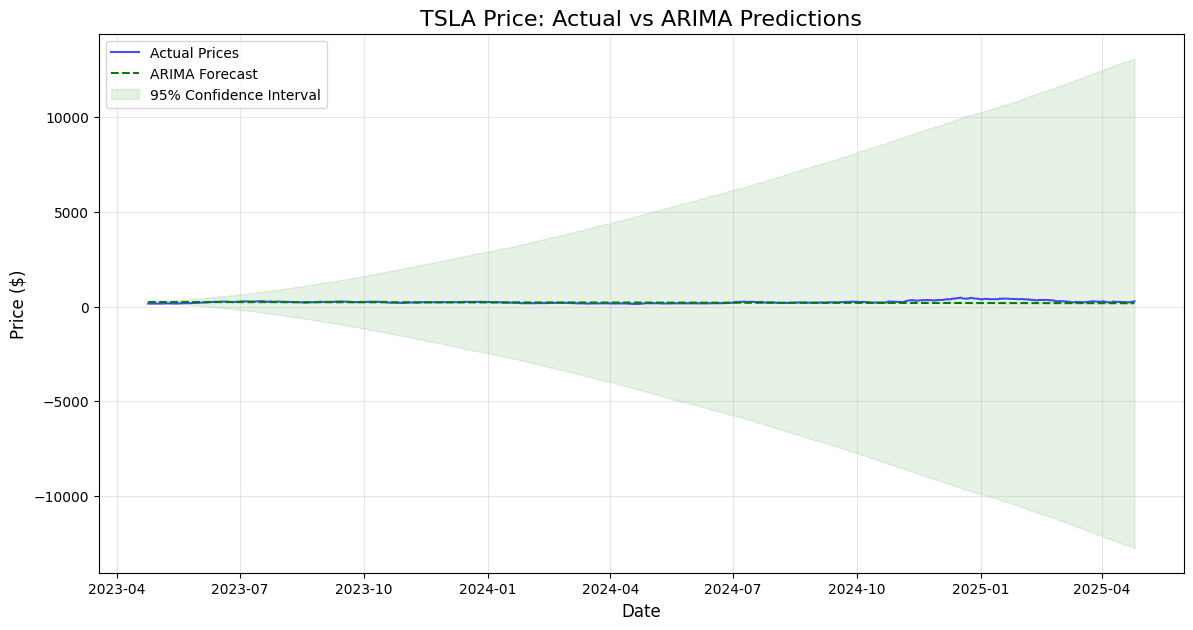

In [ ]:
# ARIMA vs Actual Price Comparison
plt.figure(figsize=(14, 7))

# Plot actual prices
plt.plot(test_arima.index, test_arima, label='Actual Prices', color='blue', alpha=0.7)

# Plot ARIMA predictions
plt.plot(test_arima.index, arima_forecast, label='ARIMA Forecast', color='green', linestyle='--')

# Add confidence intervals
plt.fill_between(test_arima.index,
                conf_int[:, 0], conf_int[:, 1],
                color='green', alpha=0.1, label='95% Confidence Interval')

# Add visual elements
plt.title(f"{stock_label} Price: Actual vs ARIMA Predictions", fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

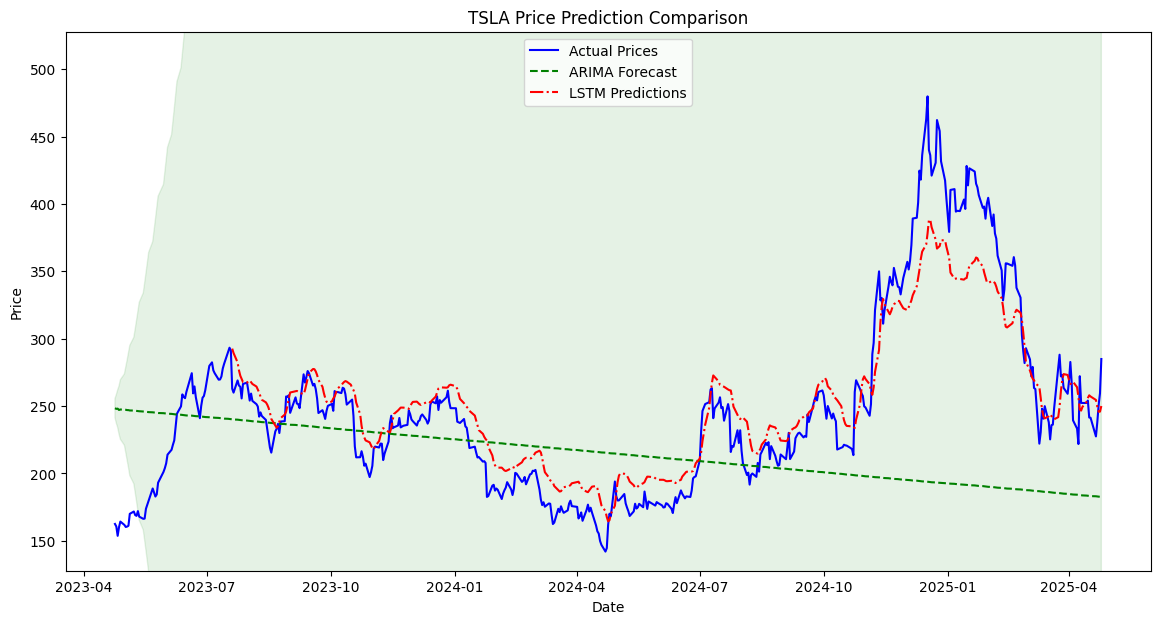

In [ ]:
# Get aligned dates for LSTM predictions (assuming seq_length=60)
lstm_dates = test_arima.index[seq_length:]

plt.figure(figsize=(14, 7))

# Plot actual prices (full test set)
plt.plot(test_arima.index, test_arima, label='Actual Prices', color='blue')

# Plot ARIMA forecast (should match test_arima length)
plt.plot(test_arima.index, arima_forecast, label='ARIMA Forecast', color='green', linestyle='--')

# Plot LSTM predictions (needs alignment)
plt.plot(lstm_dates, predictions.reshape(-1),  # Flatten LSTM predictions
         label='LSTM Predictions',
         color='red',
         linestyle='-.')

plt.fill_between(test_arima.index,
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color='green',
                 alpha=0.1)

plt.ylim(test_arima.min()*0.9, test_arima.max()*1.1)
plt.title(f"{stock_label} Price Prediction Comparison")
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()